<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/ML_In_Chem/Molecular_fingerprinting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Molecular Fingerprinting** - Kwanda Mazibuko stdnr : 1077167

<div style="text-align: center;">
   <img src="https://raw.githubusercontent.com/kwanda2426/projects/main/ML_In_Chem/molecular_finger_2.png">
</div>


# **Import RDKit Library**

In [10]:
!pip -q install rdkit

In [12]:
import rdkit
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import AllChem
from IPython.display import display

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# **Molecular Information**

Using [PubChem Database](https://pubchem.ncbi.nlm.nih.gov/) to access the SMILES representations of
- **Simvastatin**
- **Pravastatin**
- **Atorvastatin**
- **Fluvastatin**

In [16]:
# statins Dataframe
statins_list = ['Simvastatin','Pravastatin', 'Atorvastatin','Fluvastatin']
smiles_list = ['CCC(C)(C)C(=O)O[C@H]1C[C@H](C=C2[C@H]1[C@H]([C@H](C=C2)C)CC[C@@H]3C[C@H](CC(=O)O3)O)C'
               ,'CC[C@H](C)C(=O)O[C@H]1C[C@@H](C=C2[C@H]1[C@H]([C@H](C=C2)C)CC[C@H](C[C@H](CC(=O)O)O)O)O'
               ,'CC(C)C1=C(C(=C(N1CC[C@H](C[C@H](CC(=O)O)O)O)C2=CC=C(C=C2)F)C3=CC=CC=C3)C(=O)NC4=CC=CC=C4'
               ,'CC(C)N1C2=CC=CC=C2C(=C1/C=C/[C@@H](C[C@@H](CC(=O)O)O)O)C3=CC=C(C=C3)F']

# creating the statins dataframe
statins_df = pd.DataFrame({'Statins': statins_list, 'SMILES': smiles_list})

statins_df.head()

,Statins,SMILES
0,Simvastatin,CCC(C)(C)C(=O)O[C@H]1C[C@H](C=C2[C@H]1[C@H]([C@H](C=C2)C)CC[C@@H]3C[C@H](CC(=O)O3)O)C
1,Pravastatin,CC[C@H](C)C(=O)O[C@H]1C[C@@H](C=C2[C@H]1[C@H]([C@H](C=C2)C)CC[C@H](C[C@H](CC(=O)O)O)O)O
2,Atorvastatin,CC(C)C1=C(C(=C(N1CC[C@H](C[C@H](CC(=O)O)O)O)C2=CC=C(C=C2)F)C3=CC=CC=C3)C(=O)NC4=CC=CC=C4
3,Fluvastatin,CC(C)N1C2=CC=CC=C2C(=C1/C=C/[C@@H](C[C@@H](CC(=O)O)O)O)C3=CC=C(C=C3)F


# **Tanimoto Scores Between the Statins**
The Tanimoto score (also known as the Tanimoto coefficient or Jaccard index) quantifies the similarity between two sets by comparing the number of shared elements to the total number of unique elements across both sets.

In [18]:
# Create a DataFrame to store similarity scores
statin_names = statins_df['Statins'].tolist()
similarity_df = pd.DataFrame(0.0, index=statin_names, columns=statin_names)

for i in range(len(statins_df)):
  for j in range(i+1,len(statins_df)):
    # Convert SMILES strings to molecular
    mol_name_1 = statins_df['Statins'][i]
    mol_name_2 = statins_df['Statins'][j]
    mol1 = Chem.MolFromSmiles(statins_df['SMILES'][i])
    mol2 = Chem.MolFromSmiles(statins_df['SMILES'][j])
    # Generate fingerprints
    fpgen = AllChem.GetRDKitFPGenerator()
    fp1 = fpgen.GetFingerprint(mol1)
    fp2 = fpgen.GetFingerprint(mol2)

    # Calculate Tanimoto score
    t_score = DataStructs.TanimotoSimilarity(fp1,fp2)

    # Store score symmetrically
    similarity_df.loc[mol_name_1, mol_name_2] = t_score
    similarity_df.loc[mol_name_2, mol_name_1] = t_score

    # print scores
    print('The Tanimoto score between {} and {} is: {}'.format(mol_name_1,mol_name_2,t_score))
    print('')
# Fill diagonal with 1.0 (self-similarity)
for name in statin_names:
    similarity_df.loc[name, name] = 1.0

The Tanimoto score between Simvastatin and Pravastatin is: 0.8719879518072289

The Tanimoto score between Simvastatin and Atorvastatin is: 0.3004318322023442

The Tanimoto score between Simvastatin and Fluvastatin is: 0.2929368029739777

The Tanimoto score between Pravastatin and Atorvastatin is: 0.30357142857142855

The Tanimoto score between Pravastatin and Fluvastatin is: 0.3044776119402985

The Tanimoto score between Atorvastatin and Fluvastatin is: 0.5218404193360513



#### Tanimoto Similarity Heatmap

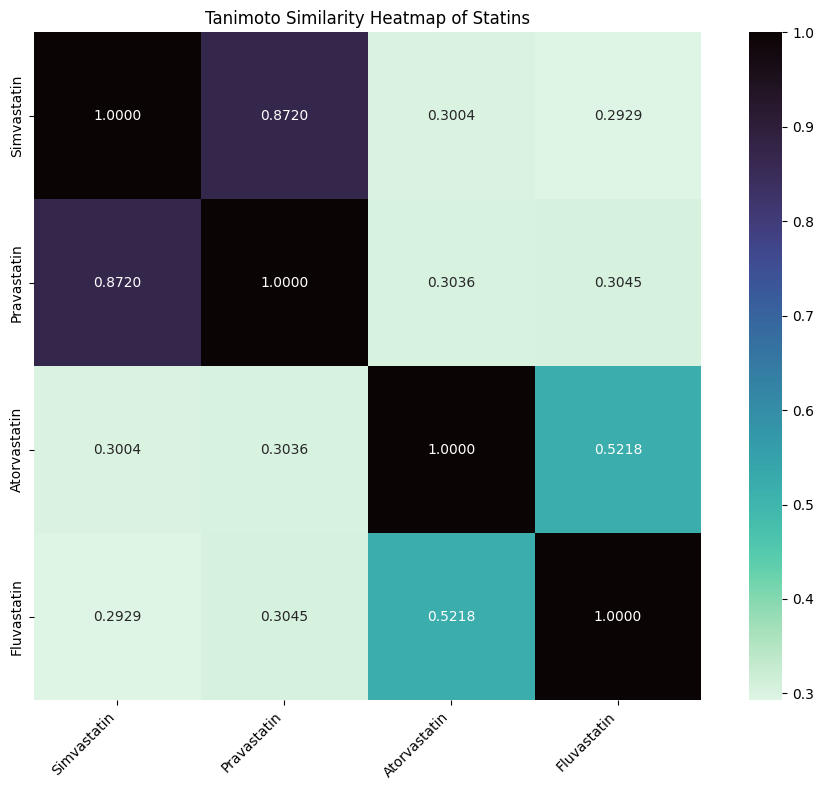

In [19]:
# Plot heatmap
plt.figure(figsize = (10, 8))
sns.heatmap(similarity_df, annot = True, cmap = 'mako_r', fmt = ".4f", square = True)
plt.title('Tanimoto Similarity Heatmap of Statins')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()


**Observations**

- Simvastatin and Pravastatin have a very high similarity score of 0.87, indicating they share a highly similar molecular fingerprint. This means that there is a strong structural resemblance and possibly similar pharmacological profiles.
- Atorvastatin and Fluvastatin show a moderate similarity of 0.52, which means that there's partial structural overlap between the statins.
- All other pairwise comparisons (Simvastatin–Atorvastatin, Simvastatin–Fluvastatin, Pravastatin–Atorvastatin, Pravastatin–Fluvastatin) show a low similarity score; between 0.29 and 0.30, meaning that they have unique molecular architectures.


# **Challenges and Potential Improvements:**


- **Canonicalisation** : This ensures SMILES are converted into a standardised, unique representation of a molecule.
Without canonicalisation, structurally identical molecules might appear different and yield misleading similarity scores. It might difficult from PubChem if the SMILES have been canonicalised.
- **Fragmented Data Categories** :
PubChem organises data into separate collections (Compound, Substance, BioAssay, etc.), which can make it difficult to navigate across related datasets.
 - **Search Difficulties** :
While PubChem has keyword and structure-based searche functionality, as someone who is not familiar with chemical nomenclature or SMILES formats, I did struggle a bit to perform precise queries.
- **Limited Guidance** : The platform often lacks intuitive guidance for interpreting complex molecular data, especially for non-experts.

The Database could have a unified search experience that seamlessly connects Compound, Substance, and BioAssay data could reduce fragmentation. Also consider implementing intelligent suggestions based on user queries could help guide users to relevant molecular data more efficiently.